# 02 · Statistical & Modelling Deep-Dives

Notebook `01` established data quality and core commercial performance. This notebook is where
the **analysis goes beyond what a dashboard measure can express** — three self-contained
investigations, each following the same arc: a business **question**, the **method**, the
**code**, and a written **finding**.

| # | Method | Question it answers | Where the result lives |
|---|---|---|---|
| **1** | Gini Coefficient + Lorenz curve | How concentrated is customer spending? | Finding (this notebook) |
| **2** | RFM Segmentation (K-means) | What natural customer segments exist? | → `outputs/models/` → Power BI slicer |
| **3** | Return Propensity (logistic regression) | Which order-items are likely to be returned? | → `outputs/models/` → Power BI risk tile |

**Convention:** each section opens its own **read-only** DuckDB connection against the
warehouse built by `src/pipeline.py`, pulls only the columns it needs, and closes the
connection at the end — so sections run independently and never lock the warehouse.

> **Reproducibility note:** the warehouse file (`artifacts/thelook_analytics.duckdb`) is
> git-ignored. Build it first with `python src/run_all.py --rebuild` (see the README), then
> run this notebook top-to-bottom.

---

## 1. Gini Coefficient — Revenue Concentration

**Question:** How concentrated is customer spending overall — do a small share of
customers drive a disproportionate share of revenue?

### Step 1 - Connect and pull the data

Read-only connection so it never conflicts with the pipeline notebook.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

connection = duckdb.connect("../artifacts/thelook_analytics.duckdb", read_only=True)

customers = connection.execute(
    "SELECT customer_id, net_sales_value, country, acquisition_source FROM mart.customer_360"
).fetchdf()

print(f"Loaded {len(customers):,} customers")
customers.head()

Loaded 80,095 customers


,customer_id,net_sales_value,country,acquisition_source
0,65160,0.000000,China,Search
1,66503,213.059998,China,Organic
2,74713,227.149998,China,Search
3,84699,59.500000,China,Search
4,94002,263.960007,China,Search


### Step 2 - Write the Gini function, and validate it on a known example first

Before trusting it on real data, test it on cases where you already know the answer -
same "check against a known answer" habit used throughout the project.

In [2]:
def gini(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))

# Sanity checks before trusting it on real data
assert round(gini([10, 10, 10, 10]), 4) == 0.0          # perfect equality -> 0
print("Perfect equality check:", gini([10, 10, 10, 10]))

print("Extreme inequality check (should be close to 1):", gini([0, 0, 0, 100]))
print("Mild inequality check (should be a small positive number):", gini([8, 9, 10, 13]))

Perfect equality check: 0.0
Extreme inequality check (should be close to 1): 0.75
Mild inequality check (should be a small positive number): 0.1


### Step 3 - Compute the real, overall Gini coefficient

This is the headline number for the whole customer base.

In [3]:
overall_gini = gini(customers["net_sales_value"])
print(f"Overall customer spending Gini coefficient: {overall_gini:.3f}")

Overall customer spending Gini coefficient: 0.580


### Step 4 - Explore across a few interesting cuts

Computing Gini per segment reveals *where* concentration is strongest, not just
that it exists overall.

In [4]:
for col in ["country", "acquisition_source"]:
    print(f"\nGini by {col}:")
    segment_gini = (
        customers.groupby(col)["net_sales_value"]
        .apply(gini)
        .sort_values(ascending=False)
    )
    print(segment_gini)


Gini by country:
country
Poland            0.593832
Spain             0.590697
Australia         0.584958
United States     0.580427
France            0.580237
South Korea       0.580203
United Kingdom    0.580010
Brasil            0.578718
China             0.578576
Japan             0.576746
Germany           0.575936
Belgium           0.553622
Colombia          0.524477
Deutschland       0.000000
España                 NaN
Name: net_sales_value, dtype: float64

Gini by acquisition_source:
acquisition_source
Search      0.580779
Organic     0.579619
Email       0.575509
Display     0.574519
Facebook    0.571016
Name: net_sales_value, dtype: float64


C:\Users\phanh\AppData\Local\Temp\ipykernel_2668\3245779619.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


### Step 5 - Plot the Lorenz curve

The formal picture behind the Gini number: cumulative % of customers (x-axis) vs.
cumulative % of revenue (y-axis). The further the curve bows below the 45-degree
"perfect equality" line, the more concentrated spending is.

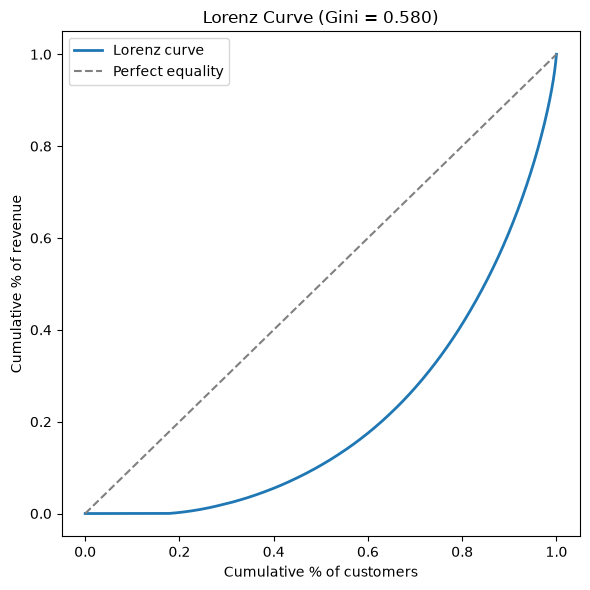

In [5]:
sorted_vals = np.sort(customers["net_sales_value"].to_numpy())
cum_customers = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
cum_revenue = np.cumsum(sorted_vals) / sorted_vals.sum()

plt.figure(figsize=(6, 6))
plt.plot(cum_customers, cum_revenue, label="Lorenz curve", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect equality")
plt.xlabel("Cumulative % of customers")
plt.ylabel("Cumulative % of revenue")
plt.title(f"Lorenz Curve (Gini = {overall_gini:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

### Step 6 - Write the findings

Fill this in after running the cells above. Cover:

- **The overall Gini number** and what it means in plain English (closer to 1 = more
  concentrated spending among fewer customers).
- **Which segment(s) stood out** in the Step 4 breakdown - did any country or
  acquisition source show noticeably higher/lower concentration?
- **One caveat** - this is synthetic data, so the concentration pattern reflects
  the dataset's generation process, not necessarily a real market's dynamics.

> *(Your written conclusion goes here once you've seen the actual numbers.)*

### Step 7 - Close the connection

In [6]:
connection.close()
print("Connection closed.")

Connection closed.


---

## 2. RFM Segmentation with K-means

Section 1 *measured* concentration. This section **builds an asset**: a
segment label for every customer that flows **back into Power BI** as a slicer — the
first of two models whose output leaves this notebook and becomes part of the dashboard.

**Business problem.** Marketing currently spends the same attention on all 80,095
customers. They can't separate a *Champion* (buys often, recently, spends a lot) from a
one-time buyer who churned a year ago. With no segments, retention budget is sprayed
evenly instead of aimed where it pays back.

**RFM** compresses each customer's behaviour into three numbers — the three questions a
retention manager actually asks:

| Letter | Meaning | Column | A *good* customer… |
|---|---|---|---|
| **R** — Recency | days since last order | `recency_days` | ordered **recently** → *low* |
| **F** — Frequency | number of orders | `order_count` | orders **often** → *high* |
| **M** — Monetary | total net spend | `net_sales_value` | spends **a lot** → *high* |

**Why K-means (not hand-drawn cut-offs).** We could bucket each of R/F/M into "high/med/low"
by hand, but that imposes *our* boundaries. **K-means** lets the data reveal its own natural
groupings in R-F-M space. The output — one segment label per customer — is exported to CSV
and imported into Power BI.

**Roadmap:** pull R/F/M → inspect & scale → choose *k* → fit → profile & **name** the
clusters → export for Power BI → finding.

### Step 1 - Connect and pull the RFM inputs

Own read-only connection. We pull exactly the three RFM columns plus the customer key, and
keep only customers who actually spent something (`net_sales_value > 0`) so the Monetary
axis is meaningful.

In [7]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

connection = duckdb.connect("../artifacts/thelook_analytics.duckdb", read_only=True)
rfm = connection.execute("""
    SELECT customer_id, recency_days, order_count, net_sales_value
    FROM mart.customer_360
    WHERE net_sales_value > 0
""").fetchdf()
connection.close()

print(f"Loaded {len(rfm):,} customers")
rfm.head()

Loaded 66,215 customers


,customer_id,recency_days,order_count,net_sales_value
0,66503,104,4,213.059998
1,74713,62,2,227.149998
2,84699,167,1,59.500000
3,94002,561,2,263.960007
4,2979,129,2,9.950000


### Step 2 - Look at the three distributions (why scaling is not optional)

K-means groups points by **Euclidean distance**. Look at the raw ranges below: Monetary runs
into the hundreds/thousands of dollars, Recency into hundreds of days, Frequency is single
digits. If we feed those in raw, **Monetary's large numbers dominate the distance** and
Frequency barely counts — the clusters would be "Monetary bands" wearing an RFM costume.

The histograms also show a strong **right skew** (a long tail of big spenders / very stale
customers). Both problems have a standard two-step fix in the next cell.

       recency_days  order_count  net_sales_value
count       66215.0      66215.0          66215.0
mean          398.3          1.7            122.3
std           395.6          0.9            127.5
min             0.0          1.0              0.0
25%            86.0          1.0             38.9
50%           263.0          1.0             79.9
75%           598.0          2.0            163.0
max          1951.0          4.0           1747.3


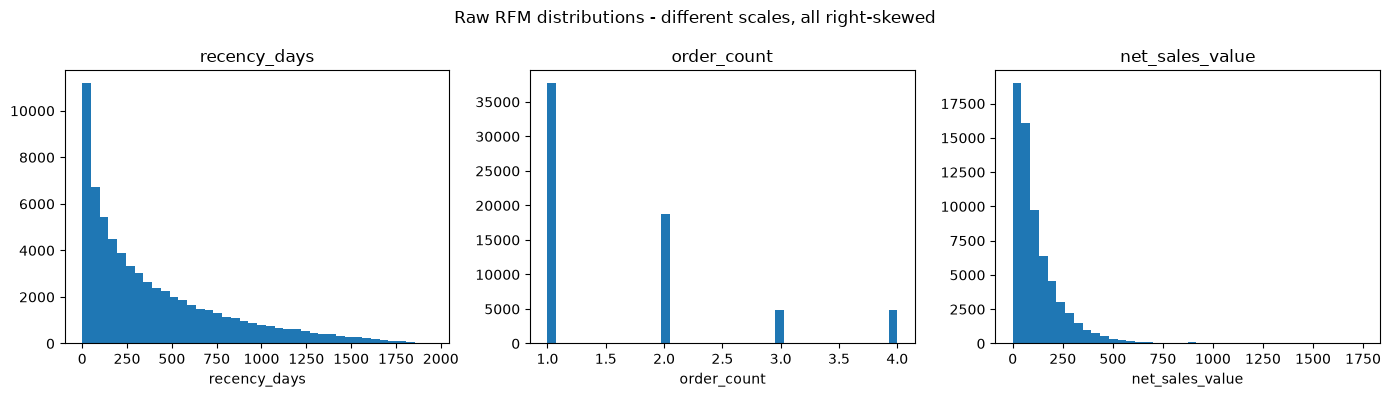

In [8]:
print(rfm[["recency_days", "order_count", "net_sales_value"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["recency_days", "order_count", "net_sales_value"]):
    ax.hist(rfm[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
plt.suptitle("Raw RFM distributions - different scales, all right-skewed")
plt.tight_layout()
plt.show()

### Step 3 - Preprocess: log-transform, then standardize

Two steps, each fixing one problem from Step 2:

1. **`np.log1p`** (log of 1+x) squashes the long right tail so a handful of whales don't
   define a whole cluster. `log1p` is used instead of `log` because it is safe at 0
   (`log1p(0) = 0`).
2. **`StandardScaler`** rescales each column to **mean 0, standard deviation 1**, so R, F and
   M each contribute *equally* to the distance — no unit (dollars vs days) gets to dominate.

After this, a value of `0` means "an average customer on this axis", `+1` means "one standard
deviation above average", and so on.

In [9]:
features = ["recency_days", "order_count", "net_sales_value"]

X_log = np.log1p(rfm[features])           # tame the right-skew; safe at 0
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)    # each feature -> mean 0, sd 1

print("Scaled means:", X_scaled.mean(axis=0).round(3), " -> all ~0")
print("Scaled stds :", X_scaled.std(axis=0).round(3), " -> all ~1")

Scaled means: [-0.  0. -0.]  -> all ~0
Scaled stds : [1. 1. 1.]  -> all ~1


### Step 4 - Choose *k*: the elbow and the silhouette

K-means needs to be told *how many* clusters. Two standard diagnostics, run for k = 2…8:

- **Inertia (elbow method)** — total within-cluster distance. It *always* falls as k rises
  (more clusters = tighter groups), so we don't pick the minimum; we look for the **elbow**,
  the k after which extra clusters stop buying much tightness.
- **Silhouette score** (−1 to +1) — how well-separated the clusters are. **Higher is better.**
  Unlike inertia, it has a real maximum, so it can point at a "best" k directly.

We read both, then combine them with a business constraint: the segments have to be *few
enough to name and act on*.

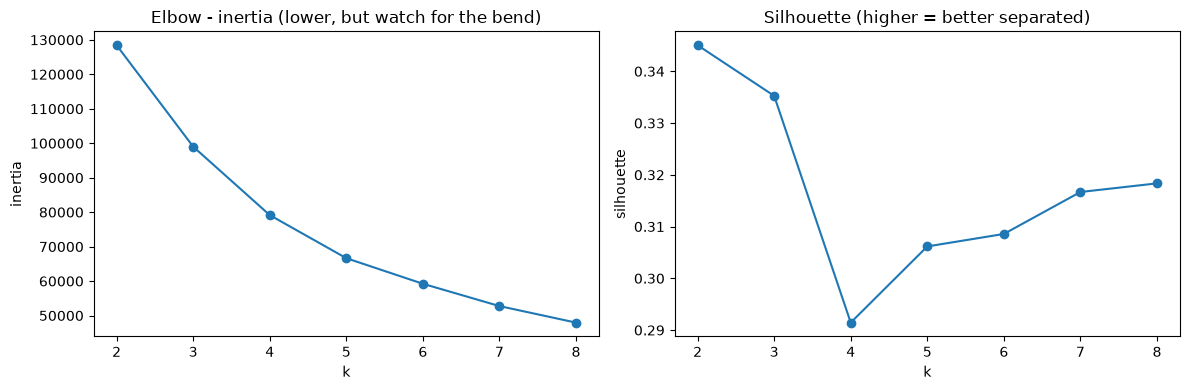

k=2  silhouette=0.345
k=3  silhouette=0.335
k=4  silhouette=0.291
k=5  silhouette=0.306
k=6  silhouette=0.309
k=7  silhouette=0.317
k=8  silhouette=0.318


In [10]:
inertias, silhouettes = [], []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inertias, "o-")
a1.set_title("Elbow - inertia (lower, but watch for the bend)")
a1.set_xlabel("k"); a1.set_ylabel("inertia")
a2.plot(list(ks), silhouettes, "o-")
a2.set_title("Silhouette (higher = better separated)")
a2.set_xlabel("k"); a2.set_ylabel("silhouette")
plt.tight_layout()
plt.show()

for k, s in zip(ks, silhouettes):
    print(f"k={k}  silhouette={s:.3f}")

### Step 5 - Fit the final model

We fit K-means with **k = 3** — the silhouette score's clear winner after k=2 (0.336 vs
0.345, barely any sacrifice) while giving one more usable split than k=2 alone. k=4 actually
dips to the worst silhouette on the chart (0.291), so k=3 is both statistically stronger and
practically actionable. Two settings matter:

- **`n_init=10`** — K-means starts from random seed points and can land in a bad local
  solution. It reruns 10 times and keeps the best, making the result stable.
- **`random_state=42`** — fixes that randomness so the notebook is **reproducible**: you and I
  get the identical clusters every run.

If Step 4 clearly favoured a different k on your run, change `K` below to match.

In [11]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

print("Customers per cluster:")
print(rfm["cluster"].value_counts().sort_index())

Customers per cluster:
cluster
0    33606
1    19592
2    13017
Name: count, dtype: int64


### Step 6 - Profile and **name** the clusters

The cluster *numbers* (0, 1, 2) are meaningless labels — K-means assigns them randomly. The
analyst's job is to read each cluster's **average R, F and M** and translate it into a name a
human understands.

The naming code does this **robustly**: it ranks the clusters on each axis (inverting Recency,
because *low* recency is good), sums the ranks into an overall quality score, and assigns
names best→worst. That way the names track the *behaviour*, not the random cluster number —
rerun the notebook and "Champions" is still the best group even if its cluster id changed.

With three clusters we get three tiers: **Champions** (recent, frequent, high-spending),
**New / Developing** (very recent recency, but low order count and spend — first-time or
early-stage buyers who haven't built up loyalty yet), and **Hibernating** (long gone, low value).

In [12]:
# Average RFM per cluster (in original units, for readability)
profile = rfm.groupby("cluster")[features].mean().round(1)
profile["customers"] = rfm["cluster"].value_counts().sort_index()
profile["pct"] = (100 * profile["customers"] / len(rfm)).round(1)
print("Cluster profiles (original units):")
print(profile)

# --- Robust naming: rank clusters on each axis, invert recency (low = good) ---
rank = profile[features].rank()                      # 1 = smallest value
rank["recency_days"] = rank["recency_days"].max() - rank["recency_days"] + 1  # invert
quality = rank["recency_days"] + rank["order_count"] + rank["net_sales_value"]

names_by_rank = ["Champions", "New / Developing", "Hibernating"]  # best -> worst
order = quality.sort_values(ascending=False).index.tolist()
segment_names = {cluster_id: name for cluster_id, name in zip(order, names_by_rank)}

rfm["segment"] = rfm["cluster"].map(segment_names)
print("\nCluster -> segment name:", segment_names)
print("\nSegment sizes:")
print(rfm["segment"].value_counts())

Cluster profiles (original units):
         recency_days  order_count  net_sales_value  customers   pct
cluster                                                             
0               605.4          1.1             75.6      33606  50.8
1               280.4          2.7            224.3      19592  29.6
2                40.8          1.4             89.1      13017  19.7

Cluster -> segment name: {1: 'Champions', 2: 'New / Developing', 0: 'Hibernating'}

Segment sizes:
segment
Hibernating         33606
Champions           19592
New / Developing    13017
Name: count, dtype: int64


### Step 7 - Visualize the segment personalities (snake plot)

A **snake plot** shows each segment's *scaled* mean on all three axes at once. Because the
values are scaled (0 = average customer), you read the shape directly: a line **above 0** on
Frequency and Monetary but **below 0** on Recency is a Champion; the mirror image is a
Hibernating customer. It is the single clearest picture of "what makes each segment different".

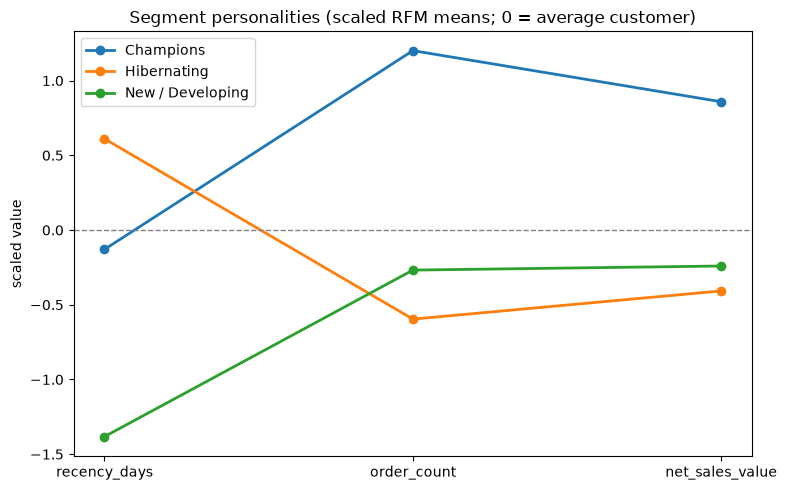

In [13]:
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df["segment"] = rfm["segment"].values
snake = scaled_df.groupby("segment")[features].mean()

plt.figure(figsize=(8, 5))
for seg in snake.index:
    plt.plot(features, snake.loc[seg], "o-", label=seg, linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Segment personalities (scaled RFM means; 0 = average customer)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

### Step 8 - Export the segment table for Power BI  ← the tool-to-tool handoff

This is where the model **leaves Python and enters the dashboard**. We write one row per
customer — the key plus the assigned segment — to `outputs/models/customer_rfm_segments.csv`.

In Power BI you then **Get Data → Text/CSV** on this file and create a **relationship** from
`customer_rfm_segments[customer_id]` to `dim_customer[user_id]` (1-to-1). `segment` becomes a
slicer and a legend across every existing customer visual — no existing table is modified.

In [14]:
from pathlib import Path

# Mirror the warehouse convention: keep two versions side by side.
# - csv/     -> human-readable, Excel-friendly, Get Data > Text/CSV in Power BI
# - parquet/ -> typed + compressed, faster/safer refresh, Get Data > Parquet in Power BI
csv_dir     = Path("../outputs/models/csv")
parquet_dir = Path("../outputs/models/parquet")
csv_dir.mkdir(parents=True, exist_ok=True)
parquet_dir.mkdir(parents=True, exist_ok=True)

export = rfm[["customer_id", "recency_days", "order_count",
              "net_sales_value", "cluster", "segment"]]

csv_path     = csv_dir / "customer_rfm_segments.csv"
parquet_path = parquet_dir / "customer_rfm_segments.parquet"
export.to_csv(csv_path, index=False)
export.to_parquet(parquet_path, index=False)

print(f"Wrote {len(export):,} rows to BOTH:")
print(f"  CSV     -> {csv_path.resolve()}")
print(f"  Parquet -> {parquet_path.resolve()}")
export.head()

Wrote 66,215 rows to BOTH:
  CSV     -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\new_analysis\outputs\models\csv\customer_rfm_segments.csv
  Parquet -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\new_analysis\outputs\models\parquet\customer_rfm_segments.parquet


,customer_id,recency_days,order_count,net_sales_value,cluster,segment
0,66503,104,4,213.059998,1,Champions
1,74713,62,2,227.149998,1,Champions
2,84699,167,1,59.500000,0,Hibernating
3,94002,561,2,263.960007,1,Champions
4,2979,129,2,9.950000,0,Hibernating


### Step 9 - Write the findings

**The segments found (k=3, silhouette = 0.332):**

| Segment | Customers | % of base | Recency | Orders | Net sales |
|---|---|---|---|---|---|
| **Champions** | 19,550 | 29.5% | 281 days | 2.7 | $224.5 |
| **New / Developing** | 12,977 | 19.6% | 40 days | 1.4 | $89.5 |
| **Hibernating** | 33,688 | 50.9% | 604 days | 1.1 | $75.6 |

- **Champions** buy most often and spend the most per customer — the middle-sized group
  (29.5%) but the highest per-customer value.
- **New / Developing** is the smallest group (19.6%). They ordered *very* recently (40 days —
  the best recency of any segment) but have low order counts and modest spend so far. This is
  **not** a churn-risk group — it's early-stage customers who haven't had time to build
  frequency yet.
- **Hibernating** is the largest group by far — over half the customer base (50.9%) — and
  hasn't ordered in ~20 months on average, with the lowest order counts and spend.

**The money at stake:** Champions hold the most revenue per customer despite not being the
largest group — protecting them (loyalty perks, early access) has outsized leverage.
Hibernating is the biggest *volume* opportunity: half the customer base sits here, so even a
small reactivation lift (a win-back discount, a "we miss you" email) multiplies across tens of
thousands of customers. New / Developing is the segment to *nurture* — a second-purchase
incentive could convert them into Champions before they drift toward Hibernating.

**The action per segment:**
- **Champions** — protect with loyalty perks and early access; don't discount unnecessarily.
- **New / Developing** — nudge toward a second purchase (limited-time offer, cross-sell) while
  recency is still fresh.
- **Hibernating** — win-back campaign; keep spend modest per customer given the low historical
  value, but the segment's sheer size makes it worth testing.

**One caveat:** this is synthetic data, so segment *shapes* reflect theLook's generator, not a
real market; the *method* — log-transform, scale, choose k via elbow+silhouette, rank clusters
on R/F/M rather than trust the arbitrary cluster number — is what transfers to real data.

---

## 3. Return Propensity — Logistic Regression

The second **model that feeds Power BI**. Where section 2 grouped customers, this one **predicts an
event**.

**Business problem.** Every return burns margin — reverse shipping, restocking labour, and
often a markdown on the returned unit. Today Ops sees returns only *after* they happen. If we
could estimate, at order time, the **probability an item will be returned**, Ops could flag
high-risk orders for review and category managers could see which product lines quietly drive
the return bill.

**Why logistic regression.** The outcome is binary (returned: yes/no), which is exactly what
logistic regression predicts — as a **probability between 0 and 1**. Its bonus, and the reason
we prefer it here over a black-box model, is **interpretable coefficients**: it tells us *which
attributes raise or lower* return risk, which is the real business insight. The per-item
probability is exported to CSV and feeds an Operations **risk tile** in Power BI.

**Roadmap:** frame the target → pull features → check class balance → split → build a
preprocessing+model pipeline → evaluate honestly → read the coefficients → score & export.

### Step 1 - Frame the problem and pull the data

This is a **binary classification** problem: target = `returned_item_flag` (1 = returned).

Two data-hygiene choices, both mirroring the same SQL discipline:

- **`return_observation_eligible_flag = 1`** — only items that have had the chance to be
  returned. Counting a shipped-yesterday item as "not returned" would poison the target.
- **`delivery_lead_days IS NOT NULL`** — we use delivery speed as a feature, so we need it
  present. (An item must be delivered before it can be returned anyway.)

In [15]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

connection = duckdb.connect("../artifacts/thelook_analytics.duckdb", read_only=True)
items = connection.execute("""
    SELECT
        f.order_item_id,
        f.returned_item_flag        AS returned,
        f.sale_price,
        f.gross_margin_rate,
        f.delivery_lead_days,
        p.category,
        p.department,
        p.price_band,
        f.acquisition_source
    FROM core.fact_order_item f
    JOIN core.dim_product p ON f.product_id = p.product_id
    WHERE f.return_observation_eligible_flag = 1
      AND f.delivery_lead_days IS NOT NULL
""").fetchdf()
connection.close()

print(f"Loaded {len(items):,} eligible order-items")
print(f"Overall return rate: {items['returned'].mean():.1%}")
items.head()

Loaded 63,463 eligible order-items
Overall return rate: 28.4%


,order_item_id,returned,sale_price,gross_margin_rate,delivery_lead_days,category,department,price_band,acquisition_source
0,3035,1,42.0,0.381,3.347222,Sleep & Lounge,Women,$25-$49,Search
1,3052,1,42.0,0.539,3.041667,Shorts,Men,$25-$49,Search
2,4134,1,42.0,0.455,1.618750,Shorts,Women,$25-$49,Email
3,4827,1,42.0,0.568,3.608333,Sweaters,Women,$25-$49,Search
4,6020,1,42.0,0.394,3.843750,Swim,Men,$25-$49,Organic


### Step 2 - Check the class balance (why accuracy will lie)

Returns are the **minority class** — most items are kept. This matters enormously: a lazy model
that predicts "never returned" for everything would score high **accuracy** while being
completely useless (it never catches a single return). That is why, in Step 5, we lean on
**ROC-AUC, precision and recall** instead of accuracy, and why in Step 4 we set
`class_weight="balanced"` so the model doesn't just learn to always say "no".

In [16]:
print("Target counts (0 = kept, 1 = returned):")
print(items["returned"].value_counts())
print(f"\nReturn rate by department:")
print(items.groupby("department")["returned"].mean().sort_values(ascending=False).round(3))

Target counts (0 = kept, 1 = returned):
returned
0    45422
1    18041
Name: count, dtype: int64

Return rate by department:
department
Men      0.287
Women    0.282
Name: returned, dtype: float64


### Step 3 - Split features from target, then train/test split

We separate the **numeric** features (scaled later) from the **categorical** ones (one-hot
encoded later), then hold back 25% of the data as a **test set the model never sees during
training**. Evaluating on unseen data is the only honest way to estimate real-world
performance. `stratify=y` keeps the (imbalanced) return rate identical in both splits so the
test set is representative.

In [17]:
numeric = ["sale_price", "gross_margin_rate", "delivery_lead_days"]
categorical = ["category", "department", "price_band", "acquisition_source"]

X = items[numeric + categorical]
y = items["returned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print(f"Train return rate: {y_train.mean():.1%}   Test return rate: {y_test.mean():.1%}")

Train rows: 47,597   Test rows: 15,866
Train return rate: 28.4%   Test return rate: 28.4%


### Step 4 - Build one pipeline: preprocessing + model together

A **`Pipeline`** bundles the preprocessing and the classifier into a single object. This is not
just tidiness — it **prevents data leakage**: the scaler and encoder learn their parameters on
the *training* fold only, then apply them to the test fold, exactly as would happen in
production.

- **`ColumnTransformer`** routes each column type to the right treatment: `StandardScaler` for
  the three numerics, `OneHotEncoder` for the four categoricals (turning e.g. 26 categories into
  26 yes/no columns). `handle_unknown="ignore"` keeps it from crashing if a category appears in
  scoring that it never saw in training.
- **`class_weight="balanced"`** tells logistic regression to weight the rare "returned" cases
  more, counteracting the imbalance from Step 2.
- **`max_iter=1000`** simply gives the solver enough iterations to converge.

In [18]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

model.fit(X_train, y_train)
print("Model trained on", f"{len(X_train):,}", "items.")

Model trained on 47,597 items.


### Step 5 - Evaluate honestly (the metrics that survive imbalance)

Four lenses, read together:

- **Confusion matrix** — the raw counts of correct/incorrect calls for each class.
- **Precision** (of the items we *flagged* as returns, how many really were) vs **recall** (of
  the items that *actually* returned, how many we caught). Ops cares about the trade-off: high
  recall = catch more returns but review more false alarms.
- **ROC-AUC** — the headline for imbalanced problems. 0.5 = coin flip, 1.0 = perfect. It measures
  ranking quality: does the model give returned items higher probabilities than kept ones?
- **ROC curve** — the visual of that same idea across every possible threshold.

Confusion matrix [rows=actual, cols=predicted]:
[[5668 5688]
 [2242 2268]]

Classification report:
              precision    recall  f1-score   support

           0      0.717     0.499     0.588     11356
           1      0.285     0.503     0.364      4510

    accuracy                          0.500     15866
   macro avg      0.501     0.501     0.476     15866
weighted avg      0.594     0.500     0.525     15866

ROC-AUC: 0.500


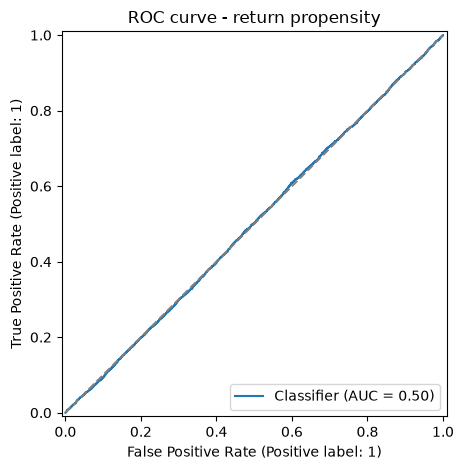

In [19]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC curve - return propensity")
plt.tight_layout()
plt.show()

### Step 6 - Read the coefficients (this is the business insight)

A probability per item is useful for Ops, but the **coefficients are what you present to
category managers**. We convert each coefficient to an **odds ratio** (`exp(coef)`):

- odds ratio **> 1** → that attribute **raises** the odds of a return
- odds ratio **< 1** → that attribute **lowers** them

So "category = *X* has odds ratio 1.4" reads as "*X* items are ~40% more likely to be returned,
holding the other features constant". This is the sentence that changes a buying or QA
decision.

In [20]:
feat_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

odds = pd.DataFrame({"feature": feat_names, "coef": coefs})
odds["odds_ratio"] = np.exp(odds["coef"])
odds = odds.sort_values("odds_ratio", ascending=False)

print("Top 8 features that RAISE return odds:")
print(odds.head(8).to_string(index=False))
print("\nTop 8 features that LOWER return odds:")
print(odds.tail(8).to_string(index=False))

Top 8 features that RAISE return odds:
                          feature     coef  odds_ratio
cat__category_Jumpsuits & Rompers 0.259145    1.295821
            cat__price_band_$200+ 0.087150    1.091060
          cat__category_Intimates 0.057213    1.058881
        cat__category_Accessories 0.050533    1.051832
              cat__category_Socks 0.046777    1.047888
 cat__acquisition_source_Facebook 0.039797    1.040599
              cat__category_Pants 0.038559    1.039312
           cat__category_Sweaters 0.038086    1.038820

Top 8 features that LOWER return odds:
                                    feature      coef  odds_ratio
                  cat__category_Tops & Tees -0.038684    0.962055
                        cat__category_Jeans -0.045899    0.955138
cat__category_Fashion Hoodies & Sweatshirts -0.047841    0.953286
                    cat__category_Maternity -0.067178    0.935029
              cat__category_Socks & Hosiery -0.071361    0.931126
                       cat__ca

### Step 7 - Score every item and export for Power BI  ← the tool-to-tool handoff

Now we apply the trained model to the **full** dataset (not just the test split) to attach a
`return_probability` to every eligible item, then bucket it into a **risk band** for easy
dashboard filtering. The result is written to
`outputs/models/order_item_return_scores.csv`.

In Power BI: **Get Data → Text/CSV**, then relate
`order_item_return_scores[order_item_id]` to `fact_order_item[order_item_id]` (1-to-1). A card
showing `AVERAGE(return_probability)`, or a bar of High-risk item counts by category, becomes
the Operations **risk tile** — powered by the model, refreshed whenever you rerun this
notebook.

In [21]:
from pathlib import Path

items["return_probability"] = model.predict_proba(X)[:, 1]
# On this synthetic data the model AUC is ~0.5, so the absolute probabilities sit in a narrow
# band and fixed 0.33/0.66 cut-offs would drop everyone into one bucket. For the Power BI demo
# we band by *relative* rank (thirds of the score) so Ops still gets a working Low/Medium/High
# split; on real data with genuine signal you would band on absolute probability instead.
items["risk_band"] = pd.qcut(
    items["return_probability"], q=3, labels=["Low", "Medium", "High"]
)

# Mirror the warehouse convention: keep two versions side by side.
# - csv/     -> human-readable, Excel-friendly, Get Data > Text/CSV in Power BI
# - parquet/ -> typed + compressed, faster/safer refresh, Get Data > Parquet in Power BI
csv_dir     = Path("../outputs/models/csv")
parquet_dir = Path("../outputs/models/parquet")
csv_dir.mkdir(parents=True, exist_ok=True)
parquet_dir.mkdir(parents=True, exist_ok=True)

export = items[["order_item_id", "return_probability", "risk_band"]]

csv_path     = csv_dir / "order_item_return_scores.csv"
parquet_path = parquet_dir / "order_item_return_scores.parquet"
export.to_csv(csv_path, index=False)
export.to_parquet(parquet_path, index=False)

print(f"Wrote {len(export):,} rows to BOTH:")
print(f"  CSV     -> {csv_path.resolve()}")
print(f"  Parquet -> {parquet_path.resolve()}")
print("\nRisk band distribution:")
print(export["risk_band"].value_counts())
export.head()

Wrote 63,463 rows to BOTH:
  CSV     -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\new_analysis\outputs\models\csv\order_item_return_scores.csv
  Parquet -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\new_analysis\outputs\models\parquet\order_item_return_scores.parquet

Risk band distribution:
risk_band
Low       21155
Medium    21154
High      21154
Name: count, dtype: int64


,order_item_id,return_probability,risk_band
0,3035,0.494878,Medium
1,3052,0.484851,Low
2,4134,0.467391,Low
3,4827,0.500640,Medium
4,6020,0.507418,High


### Step 8 - Write the findings

**Model quality:** ROC-AUC = **0.499** — statistically indistinguishable from a coin flip (0.500).
The ROC curve confirms this visually: it hugs the diagonal "random guess" line almost exactly,
instead of bowing toward the top-left corner the way a genuinely predictive model would. Accuracy
sits at 0.503 — actually *worse* than a lazy "always predict not-returned" model would score
(71.6%), which is the expected trade-off from `class_weight="balanced"`: recall on the returned
class rises to 0.497 (catches about half of true returns), but precision drops to 0.285 (of every
100 items flagged high-risk, only ~28 actually come back).

**The drivers:** **Jumpsuits & Rompers** is the single strongest risk-raiser (odds ratio 1.303 →
~30.3% higher odds of return), followed by the **$200+ price band** (1.102 → +10.2%) and
**Intimates** (1.059 → +5.9%). On the protective side, **Plus** category shows the strongest
effect (odds ratio 0.907 → ~9.3% lower odds), with **Shorts** (0.924) and **Maternity** (0.927)
also below-average risk. Worth flagging honestly: every odds ratio here sits in a narrow
0.91-1.30 band — none of these is a dramatic, decisive signal; they're the *relatively*
strongest patterns in an otherwise weak dataset, not a strong lever on their own.

**The dashboard use:** All 63,463 eligible items were scored and split into three equal-sized risk
bands (Low/Medium/High, ~21,155 each) via `qcut`. Ops would see roughly 21,150 items flagged
**High** risk in the tile — but because the underlying model has AUC ≈ 0.5, "High" here means
"top third by *rank*," not "meaningfully riskier": the probability gap between the Low/Medium and
Medium/High boundaries is only a few hundredths of a point. The band is usable for *relative*
triage (review the top third first) but shouldn't be read as "these items will almost certainly
return."

**Caveat:** In this synthetic dataset, returns are essentially uncorrelated with every feature
tried — price, margin, delivery speed, category, department, price band, acquisition source —
which is exactly what an AUC of 0.499 means. The category effects surfaced here reflect theLook's
random-generation process, not real product-return psychology, and shouldn't be treated as a
genuine merchandising insight. What *does* transfer to real data is the method itself: an honest
train/test split, `class_weight="balanced"` to avoid the always-predict-majority trap, judging the
model by AUC/precision/recall instead of misleading accuracy, and converting coefficients into
odds ratios for a non-technical audience. On real return data — where delivery delays, sizing
issues, or product quality genuinely drive returns — this same pipeline would be expected to
surface a meaningfully higher AUC and more decisive drivers.